# Análisis P1 — Datos, motor de backtesting y pruebas

Lab 02 · Equipo 3 · Nivel C

Este notebook muestra lo construido en P1: los datos del portafolio y su auditoría, cómo decide el
motor `run_backtest` en caminos cortos construidos a mano (los mismos de los golden-file tests) y la
prueba de contabilidad sobre datos sintéticos.

**Excepción declarada:** a diferencia de `analysis.ipynb`, aquí sí se corre el motor, solo sobre
caminos de pocas barras y datos sintéticos, para mostrar su comportamiento. No se optimiza nada.
Los caminos se importan de `tests/` para que lo que se ve sea exactamente lo que se prueba.

*Pendiente (requiere P2): corrida base sobre train y curva de costos.*

In [1]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from main import CONFIG
from src.backtest import run_backtest
from src.data import audit_prices, block_dates, load_prices, load_risk_free
from tests.conftest import make_synthetic_prices
from tests.test_backtest import BASE_PARAMS, causal_signals, flat, run_path

pd.set_option("display.float_format", "{:,.4f}".format)

## 1. Datos

Un CSV por activo en `data/`, descargado de Yahoo Finance con precios ajustados por splits y
dividendos (`download_prices`). `load_prices` alinea los 8 activos en un índice común sin rellenar
huecos.

In [2]:
prices = load_prices(CONFIG["tickers"])
rf = load_risk_free()
blocks = block_dates(CONFIG)
pd.DataFrame(blocks, index=["inicio", "fin"]).T

,inicio,fin
train,2018-01-01,2021-12-31
validation,2022-01-01,2023-12-31
test,2024-01-01,2026-09-30


### Auditoría de datos

Cada columna cuenta problemas por activo. Todo en 0 significa datos completos y coherentes. La
coherencia OHLC usa una tolerancia relativa de 1e-6 porque el ajuste por dividendos produce
diferencias de redondeo de ~1e-8.

In [3]:
audit_prices(prices)

,n_obs,start,end,nan,non_positive,high_lt_low,open_outside,close_outside,zero_volume,dropped_dates
AAPL,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
MSFT,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
META,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
AMD,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
XOM,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
SMH,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
GLD,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
COPX,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0


### Precios normalizados

Base 100 al inicio de la muestra. Las bandas sombreadas marcan train, validation y test.

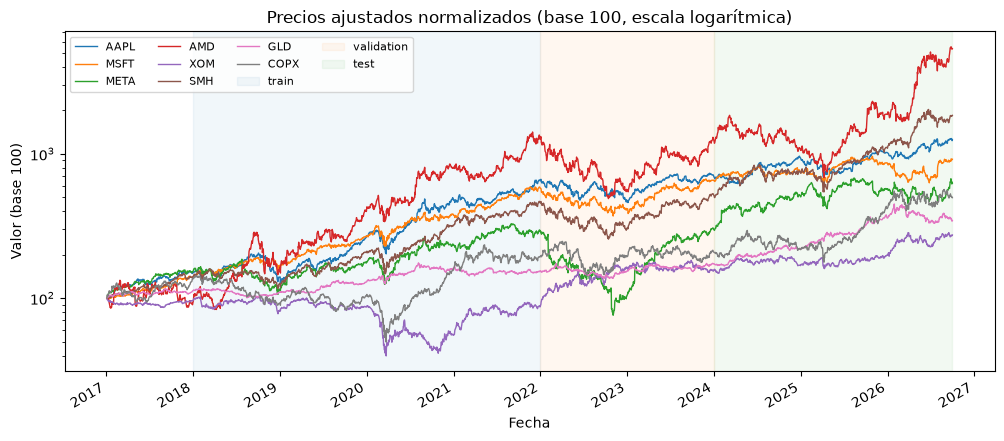

In [4]:
closes = pd.DataFrame({t: df["close"] for t, df in prices.items()})
fig, ax = plt.subplots(figsize=(12, 5))
(100 * closes / closes.iloc[0]).plot(ax=ax, logy=True, linewidth=1)
for (name, (start, end)), color in zip(blocks.items(), ["tab:blue", "tab:orange", "tab:green"]):
    ax.axvspan(start, end, alpha=0.06, color=color, label=name)
ax.set_title("Precios ajustados normalizados (base 100, escala logarítmica)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Valor (base 100)")
ax.legend(ncol=4, fontsize=8)
plt.show()

### Tasa libre de riesgo (^IRX)

Rendimiento anual del T-Bill a 13 semanas convertido a tasa diaria (÷ 100 ÷ 252). En 2020 llega a
valores ligeramente negativos: es dato real, no un error.

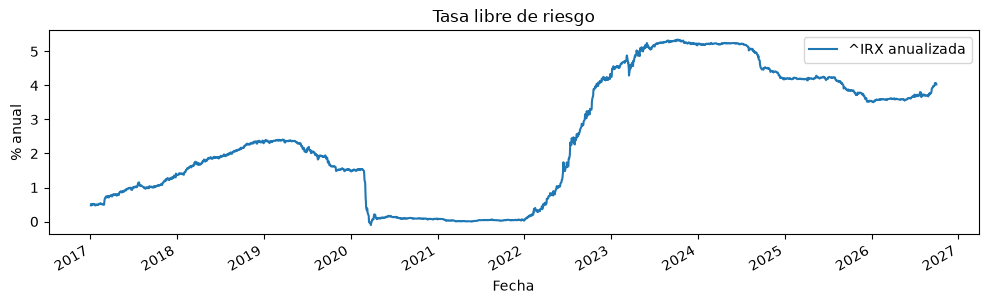

In [5]:
fig, ax = plt.subplots(figsize=(12, 3))
(rf * 252 * 100).plot(ax=ax, label="^IRX anualizada")
ax.set_title("Tasa libre de riesgo")
ax.set_xlabel("Fecha")
ax.set_ylabel("% anual")
ax.legend()
plt.show()

### Correlación de retornos en train

Solo exploratorio. Confirma la concentración declarada en SPEC.md: AAPL, MSFT, META, AMD y SMH se
mueven juntos; GLD y XOM diversifican.

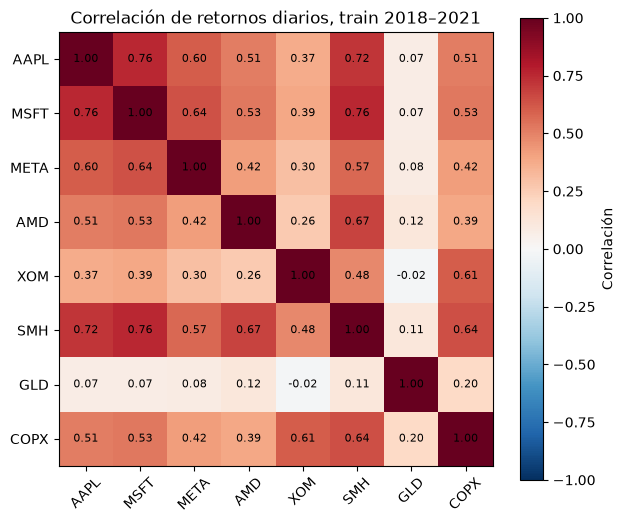

In [6]:
train_start, train_end = blocks["train"]
returns_train = closes.pct_change(fill_method=None).loc[train_start:train_end]
corr = returns_train.corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45)
ax.set_yticks(range(len(corr)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="Correlación")
ax.set_title("Correlación de retornos diarios, train 2018–2021")
plt.show()

## 2. El motor en caminos cortos

Cada camino es de un activo y pocas barras. La señal de la barra t se ejecuta al Open de t+1.
Supuestos: capital 100,000, sin costos, ATR = 1, k = 2 y r = 2. Así la distancia al stop es 2 y el
take-profit está a 4. Cada entrada usa todo el capital asignado (SPEC punto 5, v1.4): en 100 son
100,000 / 100 = 1,000 acciones.

En cada caso se muestran las ejecuciones (`fills`), las operaciones cerradas (`trades`) y el equity
final, que coincide con el calculado a mano en `tests/test_backtest.py`.

### Caso A — Stop-loss y take-profit en la misma barra

Entrada larga en 100 (SL = 98, TP = 104). La barra 2 toca 97 y 105. Convención conservadora: se
ejecuta primero el stop. Equity esperado: 100,000 − 1,000 · 2 = **98,000**.

In [7]:
bars_a = [flat(100), (100, 101, 99, 100), (100, 105, 97, 100), flat(100)]
result_a = run_path(CONFIG, bars_a, [1, 0, 0, 0])
result_a.fills

,date,ticker,side,shares,price,notional,commission,slippage,reason
0,2020-01-02,X,buy,"1,000.0000",100.0000,"100,000.0000",0.0000,0.0000,entry
1,2020-01-03,X,sell,"1,000.0000",98.0000,"98,000.0000",0.0000,0.0000,stop


In [8]:
result_a.trades[["side", "entry_price", "exit_price", "shares", "exit_reason", "pnl_net"]]

,side,entry_price,exit_price,shares,exit_reason,pnl_net
0,long,100.0000,98.0000,"1,000.0000",stop,"-2,000.0000"


In [9]:
result_a.equity

date
2020-01-01   100,000.0000
2020-01-02   100,000.0000
2020-01-03    98,000.0000
2020-01-06    98,000.0000
Freq: B, Name: equity, dtype: float64

### Caso B — Gap que abre más allá del stop

La barra 2 abre en 95, por debajo del SL de 98. No se puede vender en 98: se llena al Open.
Equity esperado: 100,000 − 1,000 · 5 = **95,000**.

In [10]:
bars_b = [flat(100), (100, 101, 99, 100), (95, 96, 94, 95), flat(95)]
result_b = run_path(CONFIG, bars_b, [1, 0, 0, 0])
result_b.trades[["entry_date", "entry_price", "exit_date", "exit_price", "exit_reason", "pnl_net"]]

,entry_date,entry_price,exit_date,exit_price,exit_reason,pnl_net
0,2020-01-02,100.0000,2020-01-03,95.0000,stop,"-5,000.0000"


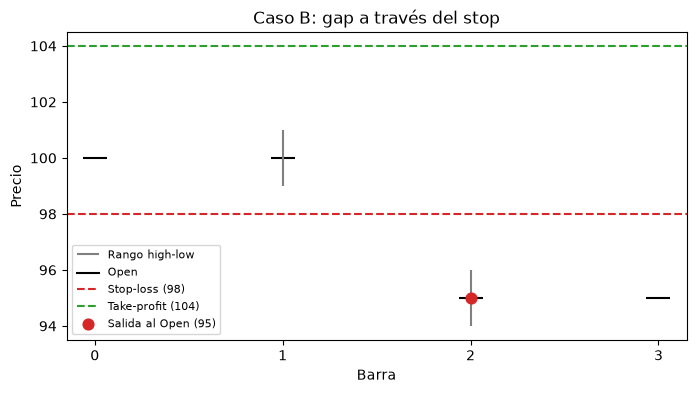

In [11]:
bar_index = range(len(bars_b))
fig, ax = plt.subplots(figsize=(8, 4))
ax.vlines(bar_index, [b[2] for b in bars_b], [b[1] for b in bars_b], color="gray", label="Rango high-low")
ax.scatter(bar_index, [b[0] for b in bars_b], marker="_", s=300, color="black", label="Open")
ax.axhline(98, color="tab:red", linestyle="--", label="Stop-loss (98)")
ax.axhline(104, color="tab:green", linestyle="--", label="Take-profit (104)")
ax.scatter([2], [95], color="tab:red", zorder=3, s=60, label="Salida al Open (95)")
ax.set_xticks(list(bar_index))
ax.set_title("Caso B: gap a través del stop")
ax.set_xlabel("Barra")
ax.set_ylabel("Precio")
ax.legend(fontsize=8)
plt.show()

### Caso C — Rearme después de un stop

Después de un stop-loss, el lado largo queda desarmado hasta que aparece una barra con señal ≠ +1.
Señales: +1, +1, +1, +1, 0, +1, 0. El stop ocurre en la barra 2; las barras 2 y 3 siguen en +1 y
**no** reentra. La barra 4 en 0 rearma, y la +1 de la barra 5 entra al Open de la barra 6 con
98,000 / 99 ≈ 989.9 acciones. Equity esperado: 98,000 + 98,000 / 99 ≈ **98,989.9**.

In [12]:
bars_c = [flat(100), (100, 101, 99, 100), (100, 100, 97, 98), flat(98),
          (98, 99, 98, 99), flat(99), (99, 100, 99, 100)]
states_c = [1, 1, 1, 1, 0, 1, 0]
result_c = run_path(CONFIG, bars_c, states_c)
result_c.fills[["date", "side", "shares", "price", "reason"]]

,date,side,shares,price,reason
0,2020-01-02,buy,"1,000.0000",100.0000,entry
1,2020-01-03,sell,"1,000.0000",98.0000,stop
2,2020-01-09,buy,989.8990,99.0000,entry


In [13]:
pd.DataFrame({"señal": states_c, "acciones al cierre": result_c.positions["X"].to_numpy(),
              "equity": result_c.equity.to_numpy()})

,señal,acciones al cierre,equity
0,1,0.0000,"100,000.0000"
1,1,"1,000.0000","100,000.0000"
2,1,0.0000,"98,000.0000"
3,1,0.0000,"98,000.0000"
4,0,0.0000,"98,000.0000"
5,1,0.0000,"98,000.0000"
6,0,989.8990,"98,989.8990"


### Caso D — Señal opuesta: reversa en el mismo Open

Largo de 1,000 acciones en 100. La señal −1 al cierre de la barra 2 cierra el largo al Open de la
barra 3 en 102 y abre un corto en ese mismo Open. El corto se dimensiona con el equity al cierre de
la barra de la señal: 101,000 / 102 ≈ 990.2 acciones. Equity esperado: **≈ 102,990.2**.

In [14]:
bars_d = [flat(100), (100, 100.5, 99.5, 100), (101, 101.5, 100.5, 101), (102, 102.5, 101.5, 101)]
result_d = run_path(CONFIG, bars_d, [1, 0, -1, 0])
result_d.fills[["date", "side", "shares", "price", "reason"]]

,date,side,shares,price,reason
0,2020-01-02,buy,"1,000.0000",100.0000,entry
1,2020-01-06,sell,"1,000.0000",102.0000,signal
2,2020-01-06,sell,990.1961,102.0000,entry


In [15]:
result_d.equity

date
2020-01-01   100,000.0000
2020-01-02   100,000.0000
2020-01-03   101,000.0000
2020-01-06   102,990.1961
Freq: B, Name: equity, dtype: float64

### Caso E — Los mismos caminos con costos reales

Comisión de 0.125% por lado, slippage de 2 bps en contra en cada llenado (incluidos SL y TP) y
borrow de 0.25% anual sobre los cortos. Costo de ida y vuelta: 29 bps.

In [16]:
cases = {"A: SL y TP misma barra": (bars_a, [1, 0, 0, 0]),
         "B: gap contra stop": (bars_b, [1, 0, 0, 0]),
         "C: rearme tras stop": (bars_c, states_c),
         "D: reversa": (bars_d, [1, 0, -1, 0])}
pd.DataFrame({
    name: {"equity sin costos": run_path(CONFIG, bars, states).equity.iloc[-1],
           "equity con costos": run_path(CONFIG, bars, states, costs=True).equity.iloc[-1]}
    for name, (bars, states) in cases.items()
}).T.assign(**{"costo total": lambda d: d["equity sin costos"] - d["equity con costos"]})

,equity sin costos,equity con costos,costo total
A: SL y TP misma barra,"98,000.0000","97,736.1536",263.8464
B: gap contra stop,"95,000.0000","94,724.8990",275.1010
C: rearme tras stop,"98,989.8990","98,580.4213",409.4777
D: reversa,"102,990.1961","102,545.3046",444.8915


## 3. Contabilidad sobre datos sintéticos (prueba 3 del lab)

3 activos sintéticos de 600 días (semilla 42), con señales causales de prueba (cruce de medias 5/20),
pesos de 1/3, largos y cortos y costos completos. Se verifica:

1. equity = efectivo + Σ acciones · close en todas las fechas;
2. Σ comisión = Σ |nocional| · 0.125%.

In [17]:
synthetic = make_synthetic_prices(n_assets=3, n_days=600, seed=42)
index = synthetic["A0"].index
result_s = run_backtest(
    synthetic,
    causal_signals(synthetic),
    pd.DataFrame(1 / 3, index=index, columns=list(synthetic)),
    pd.DataFrame(BASE_PARAMS, index=index),
    CONFIG,
)
closes_s = pd.DataFrame({t: df["close"] for t, df in synthetic.items()})
marked = result_s.cash + (result_s.positions * closes_s).sum(axis=1)
pd.Series({
    "máx |equity − (cash + posiciones)|": (result_s.equity - marked).abs().max(),
    "Σ comisión": result_s.fills["commission"].sum(),
    "Σ |nocional| · 0.125%": result_s.fills["notional"].abs().sum() * CONFIG["commission"],
    "operaciones cerradas": len(result_s.trades),
    "ejecuciones": len(result_s.fills),
})

máx |equity − (cash + posiciones)|        0.0000
Σ comisión                           94,279.3036
Σ |nocional| · 0.125%                94,279.3036
operaciones cerradas                    121.0000
ejecuciones                             243.0000
dtype: float64

In [18]:
pd.crosstab(result_s.trades["side"], result_s.trades["exit_reason"], margins=True, margins_name="total")

exit_reason,max_holding,signal,stop,target,total
side,,,,,
long,11,19,21,13,64
short,4,26,22,5,57
total,15,45,43,18,121


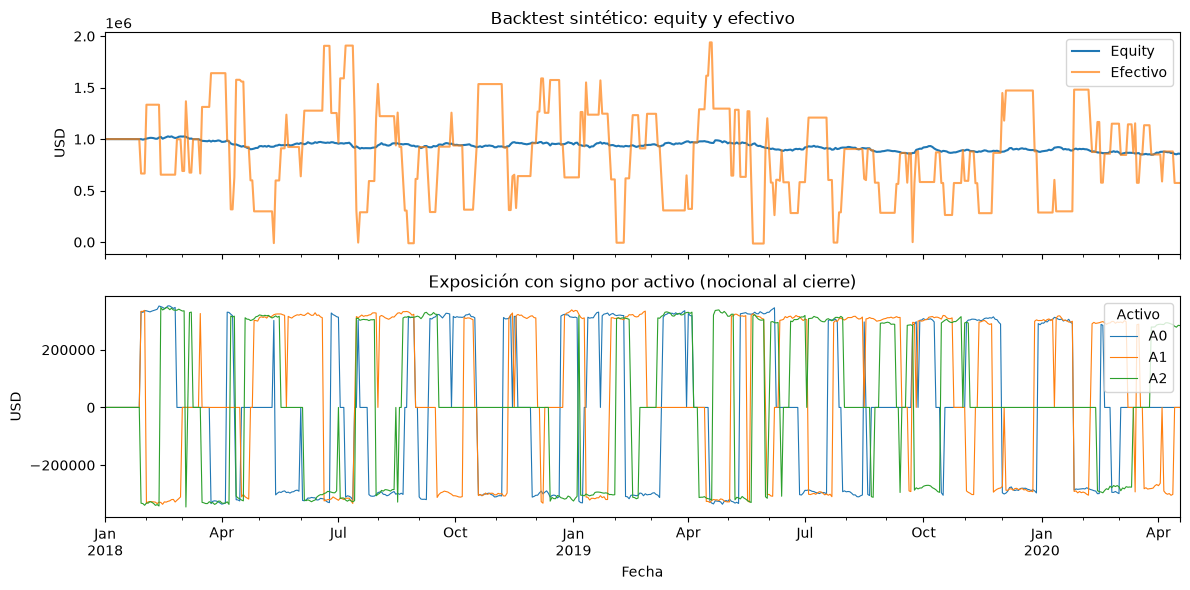

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
result_s.equity.plot(ax=axes[0], label="Equity")
result_s.cash.plot(ax=axes[0], label="Efectivo", alpha=0.7)
axes[0].set_title("Backtest sintético: equity y efectivo")
axes[0].set_ylabel("USD")
axes[0].legend()
result_s.exposure.plot(ax=axes[1], linewidth=0.8)
axes[1].set_title("Exposición con signo por activo (nocional al cierre)")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("USD")
axes[1].legend(title="Activo")
plt.tight_layout()
plt.show()

In [20]:
result_s.costs.sum().rename("costo total (USD)")

commission   94,279.3036
slippage     15,084.6760
borrow        1,707.8781
Name: costo total (USD), dtype: float64

## 4. Pruebas automatizadas

Resultado de `python -m pytest` sobre las pruebas de P1: contabilidad (prueba 3 del lab),
inmutabilidad de argumentos, 9 golden-file tests más uno con costos completos y truncamiento del
pipeline en t ∈ {100, 300, 599}.

In [21]:
import subprocess
import sys

output = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_backtest.py", "tests/test_pipeline.py", "-v", "--no-header", "--color=no"],
    capture_output=True, text=True,
).stdout
print(output)

============================= test session starts ==============================
collecting ... collected 20 items

tests/test_backtest.py::test_accounting_equity_equals_cash_plus_positions PASSED [  5%]
tests/test_backtest.py::test_accounting_commission_matches_notional PASSED [ 10%]
tests/test_backtest.py::test_run_backtest_does_not_modify_inputs PASSED  [ 15%]
tests/test_backtest.py::test_golden_1_sl_and_tp_same_bar_exits_at_stop PASSED [ 20%]
tests/test_backtest.py::test_golden_2_gap_through_stop_fills_at_open PASSED [ 25%]
tests/test_backtest.py::test_golden_3_gap_through_target_fills_at_target PASSED [ 30%]
tests/test_backtest.py::test_golden_3b_target_gap_with_full_costs PASSED [ 35%]
tests/test_backtest.py::test_golden_4a_rearm_after_target_reenters_next_bar PASSED [ 40%]
tests/test_backtest.py::test_golden_4b_no_reentry_after_stop_until_state_changes PASSED [ 45%]
tests/test_backtest.py::test_golden_5_max_holding_exits_at_open_of_bar_m_plus_1 PASSED [ 50%]
tests/test_backtest.

## 5. Pendiente

Con `signals.py` y `metrics.py` (P2) integrados se agregan aquí:

- la corrida base sobre train con los valores base del SPEC (θ único), por activo y con pesos iguales:
  equity, drawdown y operaciones;
- la curva de sensibilidad a costos (`cost_sweep`).

La lista completa está en `instrucciones/P1_datos_motor.md`, sección "Estado y pendientes".